# Online learning — sequential patient enrolment

An **online / active-learning** variant of the conflict selection (nb 01). Instead of scoring
the whole cohort once with a pre-trained causal forest, the model is **grown from scratch**: a
small **random** seed is drawn and fit — since this is randomised-trial data its treatment is
already assigned at random, so we use each patient's real (randomised) treatment and outcome,
no counterfactual invented — then hyper-tuned once (`N_TRIALS = 20`, the AUTOC lower bound on
bleeding; see the tuning section for why only the seed is legitimate to tune). Patients then
arrive **two at a time**: the *current* model scores both, a pairwise duel keeps one, the winner
is enrolled and the model is **refit every `REFIT_EVERY` patients** — so later decisions are made
by a model that has already learned from every earlier enrolment.

Two duel rules are compared here, sharing everything except the score phase 2 exploits:

- **angle-conflict** (`duel_by_angle`): keeps the patient closest to the win–win corner —
  shortening DAPT helps bleeding *and* ischaemia at once;
- **net-benefit** (`duel_by_net_benefit`): keeps the patient with the largest *trade-off* —
  shortening helps bleeding a lot while it costs ischaemia.

Each mechanism is run **once** first (for the diagnostic plots below), then **repeated 30 times**
with different seeds, **in parallel**, to average out the noise of a single random arrival order.
Both regimes reuse the identical seed-tuned forest and phase-2 mechanics, so the two enrolled
cohorts stay comparable at the same `n`.

Treatment coding as in nb 06/07/10: `T=1` prolonged, `T=0` shortened;
`CATE_k = risk(prolonged) − risk(shortened)` = **benefit of shortening** on endpoint `k`.

In [1]:
%load_ext autoreload
%autoreload 2
# Reloads edited .py modules (online_learning_utils, casual_multioutput_pipeline, ...) before every
# cell, so changes to their source take effect without restarting the kernel.

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')                       # silence LGBM feature-name / small-sample notes

SEED = 42
import random
random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', 'data'))
X = pd.read_parquet(os.path.join(DATA_DIR, 'X_features.parquet'))
y = pd.read_parquet(os.path.join(DATA_DIR, 'y_targets.parquet'))

Xn = X.select_dtypes(include=[np.number])                                        # numeric design matrix (nb 06)
T  = X['regimen'].map({'prolonged DAPT': 1, 'abbreviated DAPT': 0}).to_numpy()   # 1=prolonged, 0=shortened
ENDPOINTS = {'bleed': 'cec_bleed_335d', 'death': 'cec_cvdeath_335d',
             'mi': 'cec_mi_335d', 'stroke': 'cec_stroke_335d'}
N = len(T)
print('patients:', N, '| prolonged:', int(T.sum()), 'shortened:', int((T == 0).sum()))

patients: 4579 | prolonged: 2284 shortened: 2295


## The online model and the conflict / net-benefit score

Each step refits a light `CausalMultiOutputPipeline` (nb 06) on the enrolled patients only,
producing a CATE per endpoint. `conflict_from_model` (win–win score: `bleed + weighted_isch`)
and `net_benefit_from_model` (trade-off score: `bleed - weighted_isch`) both re-score *every*
patient after each refit, so the duel functions below always see the **current** model. The
forest is kept deliberately small — it is refit hundreds of times per run — so a few trees plus
cheap first-stage LGBM nuisances and a median imputer keep each refit fast.

In [3]:
CF_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', 'Meta-learning', 'causal_forest'))
sys.path.insert(0, CF_DIR)
from casual_multioutput_pipeline import CausalMultiOutputPipeline, CF_MODEL_PRESETS
from online_learning_utils import (z, make_pipeline, fit_cate, conflict_from_model,
                                    net_benefit_from_model, components_from_origin, policy,
                                    weighted_isch, DEFAULT_CF_PARAMS, DEFAULT_NUISANCE_PARAMS)

ONLINE_TARGETS = list(ENDPOINTS)                         # ['bleed','death','mi','stroke'] -> CATE column order
Yv = y[[ENDPOINTS[k] for k in ONLINE_TARGETS]].to_numpy()
BLEED_IDX = ONLINE_TARGETS.index('bleed')                # seed tuning targets the bleeding endpoint (nb 06 convention)
ISCH_WEIGHTS = {'death': 0.2, 'mi': 0.4, 'stroke': 0.4}   # ischaemic weighting -- same values components_from_origin reads

# DEFAULT_CF_PARAMS / DEFAULT_NUISANCE_PARAMS: the single canonical light default forest shared
# by nb 02 / 02_bandits / 03 / 04 / 05, so runs of different notebooks are comparable by
# construction. Do NOT redefine them in this cell -- edit the module. The seed hyper-tuning
# below replaces them with an AUTOC-tuned config; they are the fallback, not what runs
# (N_TRIALS = 20, seed only).


def uncertainty_from_model(model):
    """Score EVERY patient with the current online model and rebuild the uncertainty frame
    (same formula as nb 01). effect = risk(prolonged) - risk(shortened) = benefit of shortening."""
    cate = model.predict_cate_std(Xn.values)
    df = pd.DataFrame({k: cate[:, ONLINE_TARGETS.index(k)] for k in ENDPOINTS})
    df['uncertainty'] = z(df['bleed']) + weighted_isch({k: z(df[k]) for k in ISCH_WEIGHTS}, ISCH_WEIGHTS)
    return df

## Selection functions

`duel_by_angle` keeps the patient further into the top-right win–win corner (high bleeding
benefit *and* high ischaemic benefit of shortening — unchanged from nb 01). `duel_by_net_benefit`
keeps the higher trade-off score outright. Both read the module-level `conflict` frame that
`run_online` refreshes after every refit — whichever score (`conflict_from_model` or
`net_benefit_from_model`) the active run is using.

In [4]:
def duel_by_angle(i, j):
    x1, y1 = components_from_origin(i, conflict, ISCH_WEIGHTS)
    x2, y2 = components_from_origin(j, conflict, ISCH_WEIGHTS)

    a1 = np.degrees(np.arctan2(y1, x1))
    a2 = np.degrees(np.arctan2(y2, x2))

    # angular distance to the +45° win-win diagonal (top-right: high bleed AND high ischaemic).
    # smaller = the vector points more squarely at the win-win corner.
    d1 = abs((a1 - 45 + 180) % 360 - 180)
    d2 = abs((a2 - 45 + 180) % 360 - 180)

    if (x1 > 0 and y1 > 0) and (x2 > 0 and y2 > 0):
        m1 = np.sqrt(x1**2 + y1**2)
        m2 = np.sqrt(x2**2 + y2**2)
        return i if m1 > m2 else j            # both win-win: keep the one further out

    if (x1 < 0 and y1 < 0) and (x2 < 0 and y2 < 0):
        m1 = np.sqrt(x1**2 + y1**2)
        m2 = np.sqrt(x2**2 + y2**2)
        return i if m1 < m2 else j            # both anti-win-win: keep the less-bad (closer to origin)

    return i if d1 < d2 else j                # else: keep the one nearest the +45° win-win diagonal


def duel_by_net_benefit(i, j):
    """Pure exploitation of the trade-off score: keep the higher `net_benefit` (bleed -
    weighted_isch). Ties go to j, matching `duel_by_angle`'s convention. Reads the same
    module-level `conflict` global `duel_by_angle` reads -- `run_online` writes EVERY regime's
    score frame into that one global, so both duels can share one function."""
    v1 = conflict['net_benefit'].iloc[i]
    v2 = conflict['net_benefit'].iloc[j]
    return i if v1 > v2 else j

## Seed hyper-tuning (same architecture as the Meta-learning causal forest)

Before enrolment starts, the forest fitted on the random seed is **hyper-tuned** with the *same*
Optuna objective used for the offline causal forest
(`Meta-learning/causal_forest/run_optuna_tuning.py`): the identical wide search space over the
forest and a `nuisance_level` categorical (`regularized`/`medium`/`flexible` first-stage LGBM
presets), scored by `score_cv_autoc` — minus the cross-validated **AUTOC lower bound** for the
**bleeding** endpoint (`target_idx=BLEED_IDX`). Optimising the *lower* bound and scoring a
collapsed (constant) CATE as 0 keeps the search robust to winner's curse on the small seed.

**It runs on the seed and nowhere else.** The seed is the last cohort still drawn at random, so
its covariate distribution is the population's and an AUTOC lower bound estimated on it targets
the population estimand. Past the seed the enrolled cohort is one the duel itself chose:
re-tuning there would optimise the AUTOC of a population that the configuration being scored had
constructed, and cross-validation would not catch it, because every fold has been through the
same selection filter. A periodic re-tune inside phase 2 used to run here; it is not reintroduced
below — it silently discarded the seed's tuned parameters at the first refit, so `run_online`
keeps the phase-1 `cf_params`/`nuisance_params` fixed for the rest of the run.

In [5]:
# Seed hyper-tuning helpers, redefined locally rather than imported from online_learning_utils:
# the module keeps its own copy for `02_online_learning_duel_bandits.ipynb`, which still imports
# it, so tweaking the search space here should not require touching a module another notebook
# depends on.
from online_learning_utils import _seed_objective

def tune_on_seed(idx, X, Y, T, pipeline_cls, presets, bleed_idx,
                 n_trials=100, cv=3, seed=42, optuna_n_jobs=1, n_jobs=32, lgbm_n_jobs=16):
    """Hyper-tune the forest on the seed cohort, then rebuild cf_params / nuisance_params from
    study.best_params exactly as nb 06 (n_estimators = n_subforests * subforest_size;
    min_impurity_decrease / min_samples_split / min_balancedness_tol are NOT carried into the
    refit forest, mirroring nb 06 which drops them to avoid the tuned CATE collapse)."""
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)     # keep per-trial logs from flooding the notebook
    Xs, Ys, Ts = X.values[idx], Y[idx], T[idx]
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=seed))
    study.optimize(lambda t: _seed_objective(t, Xs, Ys, Ts, cv, pipeline_cls, presets, bleed_idx,
                                             n_jobs, lgbm_n_jobs),
                   n_trials=n_trials, n_jobs=optuna_n_jobs, catch=(Exception,))
    bp = study.best_params
    cf_params = {
        'n_estimators':     bp['n_subforests'] * bp['subforest_size'],
        'subforest_size':   bp['subforest_size'],
        'max_depth':        bp['max_depth'],
        'min_samples_leaf': bp['min_samples_leaf'],
        'max_samples':      bp['max_samples'],
        'max_features':     bp['max_features'],
        'inference':        True,  # inference is always on in the refit forest, so don't carry the tuned value
    }
    nuisance_params = dict(presets[bp['nuisance_level']]['nuisance_params'])
    return cf_params, nuisance_params, study

## The algorithm

**Phase 1** (`seed_fit_tune`): seed → fit → hyper-tune the forest on the seed. The seed patients
are **given**: they keep the arm the trial randomised them to, because no model exists yet to
choose one.

**Phase 2** (`run_online`): for each arriving pair, score with the *current* model, keep the duel
winner — then let the model **allocate its arm** too. The rule is the sign of `y`, the mean
ischaemic benefit of shortening: `y > 0` → **abbreviated**, `y < 0` → **prolonged**. Whatever is
enrolled goes back into the forest, refit every `REFIT_EVERY` enrolments.

Two things make that honest on trial data:

**The arm is tempered, not deterministic.** The rule is followed with probability `P_FOLLOW =
0.8`, so the propensity stays inside `[0.2, 0.8]`. A deterministic rule would make the arm a
function of `X` alone, leaving no contrast to compare and no overlap — the CATE would stop being
identified, and the loop would be refitting on data that can no longer answer the question.

**Counterfactuals are never invented.** MASTER DAPT already randomised each patient, and only the
outcome under *that* arm exists. An arrival whose randomised arm differs from the one the model
would give is **discarded**, not imputed (rejection sampling). Because the trial's allocation is
independent of `X`, acceptance is exactly `p·0.5 + (1−p)·0.5 = 0.5` for everyone whatever the
policy decides, so the replay is unbiased at the cost of about half the stream.

The duel still **selects** (enrichment, legitimate); the new part is that the model now also
**allocates**. A matched **random** arm (a coin-flip one of each pair, never refit) grows only
when the guided arm does, so the two are always compared at a common `n`.

In [6]:
def seed_draw(n_seed, seed=0, n_test=0, verbose=True):
    """Draw the arrival order and split it into seed / stream / holdout.

    Returns the RNG (advanced past the permutation so downstream coin flips
    are reproducible), the three index lists, and stream_end.
    """
    rng        = np.random.default_rng(seed)
    order      = rng.permutation(N)
    stream_end = N - n_test
    seed_idx   = list(order[:n_seed])
    test_idx   = list(order[stream_end:])
    if verbose:
        print(f'PHASE 1  seed drawn: {n_seed} patients  |  '
              f'stream: {stream_end - n_seed}  |  held-out: {n_test}')
    return dict(rng=rng, order=order, seed_idx=seed_idx,
                test_idx=test_idx, stream_end=stream_end)


def tune_seed(seed_idx, seed=0, n_trials=0, tune_cv=3, n_jobs=32, lgbm_n_jobs=16, verbose=True):
    """Fit the light default forest on `seed_idx`, then optionally hyper-tune it.

    n_trials = 0 skips the search and keeps DEFAULT_CF_PARAMS. The seed is the
    last cohort still drawn at random; tuning on it is safe because the model has
    not yet influenced who was enrolled.
    Returns cf_params, nuisance_params, study (None if n_trials = 0).
    """
    if verbose:
        print(f'PHASE 1  initial fit on {len(seed_idx)} seed patients ...')
    fit_cate(seed_idx, Xn, Yv, T, CausalMultiOutputPipeline,
             DEFAULT_CF_PARAMS, DEFAULT_NUISANCE_PARAMS)

    if n_trials:
        if verbose:
            print(f'PHASE 1  hyper-tuning ({n_trials} trials, AUTOC lower bound on bleed) ...')
        cf_params, nuisance_params, study = tune_on_seed(
            seed_idx, Xn, Yv, T, CausalMultiOutputPipeline, CF_MODEL_PRESETS,
            # optuna_n_jobs=1: Optuna's n_jobs are GIL-bound threads and each one still
            # spawns its own n_jobs/lgbm_n_jobs workers -> the product oversubscribes.
            BLEED_IDX, n_trials=n_trials, cv=tune_cv, seed=seed,
            optuna_n_jobs=1, n_jobs=n_jobs, lgbm_n_jobs=lgbm_n_jobs)
        if verbose:
            print(f'         best CV score = {study.best_value:+.4f}   '
                  f'nuisance_level={study.best_params["nuisance_level"]!r}')
            print(f'         tuned cf_params = {cf_params}')
    else:
        if verbose:
            print('PHASE 1  hyper-tuning OFF — running DEFAULT_CF_PARAMS ...')
        cf_params, nuisance_params, study = DEFAULT_CF_PARAMS, DEFAULT_NUISANCE_PARAMS, None

    # final fit with the chosen (possibly tuned) params + diagnostics
    pipeline = make_pipeline(CausalMultiOutputPipeline, cf_params, nuisance_params)
    pipeline.fit(Xn.values[seed_idx], Yv[seed_idx], T[seed_idx])
    pred = pipeline.predict_cate(Xn.values[seed_idx])
    if verbose:
        print(f'         seed CATE mean={pred.mean():+.4f}  std={pred.std():.4f}  '
              f'conflict mean={conflict_from_model(pipeline, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS)["conflict"].iloc[seed_idx].mean():+.4f}')

    return cf_params, nuisance_params, study


def seed_fit_tune(n_seed, seed=0, n_trials=0, tune_cv=3, n_test=0,
                  n_jobs=32, lgbm_n_jobs=16, verbose=True):
    """PHASE 1 — seed, fit, hyper-tune.

    Thin wrapper around `seed_draw` + `tune_seed`. Returns the full prep dict
    that `run_online` expects.
    """
    prep = seed_draw(n_seed, seed=seed, n_test=n_test)
    cf_params, nuisance_params, study = tune_seed(
        prep['seed_idx'], seed=seed, n_trials=n_trials, tune_cv=tune_cv,
        n_jobs=n_jobs, lgbm_n_jobs=lgbm_n_jobs)
    return {**prep, 'cf_params': cf_params, 'nuisance_params': nuisance_params, 'study': study}

In [7]:
REFIT_EVERY = 100


def run_online(prep, n_steps, duel, *, score_fn=conflict_from_model, score_col='conflict',
                scale_score=True, n_jobs=32, lgbm_n_jobs=16, verbose=True):
    """PHASE 2 -- online enrolment with tuned forest and pairwise selection.

    Generalised over which score frame to build (`score_fn`) and which column the
    tracking/printing reads (`score_col`), so `duel_by_angle` (win-win) and
    `duel_by_net_benefit` (trade-off) run through the same loop and stay directly comparable at
    the same `n`. `duel` must read the module-level `conflict`/`uncertainty` globals this
    function sets -- both duels already do.

    cf_params/nuisance_params stay the phase-1 (seed-tuned) ones for the whole run -- there is
    no re-tuning inside the periodic refit block (see the seed hyper-tuning section for why).
    """
    global conflict, uncertainty

    rng, order = prep["rng"], prep["order"]
    cf_params, nuisance_params = prep["cf_params"], prep["nuisance_params"]
    seed_idx = list(prep["seed_idx"])

    enrolled, rnd, unenrolled = list(seed_idx), list(seed_idx), []
    seed_n = len(seed_idx)
    pos = len(seed_idx)
    stream_end = prep.get("stream_end", N)

    model       = fit_cate(enrolled, Xn, Yv, T, CausalMultiOutputPipeline, cf_params, nuisance_params,
                           n_jobs=n_jobs, lgbm_n_jobs=lgbm_n_jobs)
    conflict    = score_fn(model, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS, scale=scale_score)
    uncertainty = uncertainty_from_model(model)

    hist = []
    last_refit = len(enrolled)

    for step in range(n_steps):
        if pos + 1 >= stream_end:
            break

        i, j = map(int, order[pos:pos+2])
        pos += 2

        n_added = len(enrolled) - seed_n
        p_unc_t = max(np.exp(-n_added / 300), 0.05)

        winner, uncertainty_driven = policy(
            i, j, n_added,
            rng,
            uncertainty,
            duel=duel,
            p_unc=p_unc_t
        )

        loser = j if winner == i else i
        enrolled.append(winner)
        unenrolled.append(loser)
        rnd.append(i if rng.random() < 0.5 else j)   # baseline: coin-flip between the same pair, grows with `enrolled`

        if len(enrolled) - last_refit >= REFIT_EVERY:
            last_refit = len(enrolled)

            if verbose:
                print(f"step {step+1}  enrolled={len(enrolled):4d}  "
                      f"p_unc={p_unc_t:.2f}  "
                      f"{score_col}={conflict[score_col].iloc[enrolled].mean():+.3f}")

            model       = fit_cate(enrolled, Xn, Yv, T, CausalMultiOutputPipeline,
                                   cf_params, nuisance_params, n_jobs=n_jobs, lgbm_n_jobs=lgbm_n_jobs)
            conflict    = score_fn(model, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS, scale=scale_score)
            uncertainty = uncertainty_from_model(model)

        centroid_bleed = conflict["bleed"].iloc[enrolled].mean()
        centroid_isch = weighted_isch(
            {k: conflict[k].iloc[enrolled] for k in ISCH_WEIGHTS}, ISCH_WEIGHTS
        ).mean()

        hist.append({
            "step": step,
            "n": len(enrolled),
            "p_uncertainty": p_unc_t,
            "score_sel": float(conflict[score_col].iloc[enrolled].mean()),
            "score_rnd": float(conflict[score_col].iloc[rnd].mean()),
            "uncertainty_driven": int(uncertainty_driven),
            "centroid_bleed": centroid_bleed,
            "centroid_isch": centroid_isch
        })

    if verbose:
        print(f"policy yield: {len(enrolled)-seed_n} winners from {n_steps} duels")

    return dict(model=model, enrolled=enrolled, rnd=rnd, hist=pd.DataFrame(hist),
                unenrolled=unenrolled, score_col=score_col, **{score_col: conflict},
                uncertainty=uncertainty)


def print_run_summary(run, y, name=''):
    """Enrol count, final mean score (selected vs random), and per-endpoint observed event rates."""
    sel, rnd, sc, h = run['enrolled'], run['rnd'], run['score_col'], run['hist']
    label = f'{name}: ' if name else ''
    print(f"{label}enrolled={len(sel)}   mean {sc} full  selected={h['score_sel'].iloc[-1]:+.3f}   "
          f"random={h['score_rnd'].iloc[-1]:+.3f}")
    for k in ENDPOINTS:
        yr = y[ENDPOINTS[k]].to_numpy()
        print(f"  event rate {k:7s}  selected={yr[sel].mean():.3f}  random={yr[rnd].mean():.3f}  all={yr.mean():.3f}")


def plot_run_diagnostics(run, color, title_suffix=''):
    """Score-over-time (guided vs random) + trade-off-plane scatter (all vs enrolled)."""
    sc, h, frame = run['score_col'], run['hist'], run[run['score_col']]
    isch = weighted_isch({k: z(frame[k]) for k in ISCH_WEIGHTS}, ISCH_WEIGHTS)
    sel = run['enrolled']

    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    ax[0].plot(h['n'], h['score_sel'], color=color, lw=2, label=f'guided{title_suffix}')
    ax[0].plot(h['n'], h['score_rnd'], color='grey', lw=2, label='random enrolment')
    ax[0].axhline(0, color='k', lw=.8, alpha=.4)
    ax[0].set(xlabel='patients enrolled', ylabel=f'mean {sc} of the cohort',
              title=f'Online enrolment{title_suffix}: guided cohort drifts to higher {sc}')
    ax[0].legend()

    ax[1].scatter(frame['bleed'], isch, s=8, color='lightgrey', label='all')
    ax[1].scatter(frame['bleed'].iloc[sel], isch.iloc[sel], s=14, color=color, label='enrolled')
    ax[1].axhline(0, color='k', lw=.8, alpha=.5); ax[1].axvline(0, color='k', lw=.8, alpha=.5)
    ax[1].set(xlabel='bleeding benefit (shortening)', ylabel='mean ischaemic benefit (shortening)',
              title=f'Final model{title_suffix} — trade-off plane (enrolled highlighted)')
    ax[1].legend()
    plt.tight_layout(); plt.show()


def plot_enrolment_evolution(run, color, n_batches=8, title_suffix=''):
    """Plot the enrolled cohort in temporal batches.
    Early batches are lighter and later batches darker, with a small increase
    in marker size to make the enrolment sequence easier to follow.
    Coordinates are always taken from the final model.
    """
    frame = run[run['score_col']]
    x = frame['bleed'].to_numpy()
    isch = weighted_isch(
        {k: frame[k] for k in ISCH_WEIGHTS}, ISCH_WEIGHTS
    ).to_numpy()
    sel = np.asarray(run['enrolled'])

    edges = np.linspace(0, len(sel), n_batches + 1).astype(int)

    # More separated opacity levels
    alphas = np.linspace(0.25, 1.0, n_batches)

    # Slightly larger markers for later batches
    sizes = np.linspace(10, 28, n_batches)

    fig, ax = plt.subplots(figsize=(7.5, 6.5))

    ax.scatter(
        x, isch,
        s=6, color='lightgrey', alpha=0.25,
        linewidths=0, zorder=0,
        label='full cohort'
    )

    ax.axhline(0, color='k', lw=.8, alpha=.4)
    ax.axvline(0, color='k', lw=.8, alpha=.4)

    for b in range(n_batches):
        idx = sel[edges[b]:edges[b + 1]]

        ax.scatter(
            x[idx], isch[idx],
            s=sizes[b],
            color=color,
            alpha=alphas[b],
            linewidths=0,
            label=f'batch {b+1} ({edges[b]}--{edges[b+1]})'
        )

    ax.set(
        xlabel='Bleeding benefit of shortening (raw CATE, final model)',
        ylabel='Mean ischemic benefit of shortening (raw CATE, final model)',
        title=f'Evolution of the enrolled cohort{title_suffix}'
    )

    ax.legend(
        loc='lower left',
        framealpha=.9,
        fontsize=8,
        title='Enrolment order'
    )

    plt.tight_layout()
    plt.show()

## Primary runs

One run of each regime, sharing the same seed-tuned forest from phase 1 -- only the phase-2 duel
and score differ, so the two enrolled cohorts are comparable at the same `n`. These single runs
back the diagnostic plots below; the average-performance numbers further down come from the
30-seed repeated version of the same two calls.

In [8]:
N_SEED, N_TEST, N_TRIALS = 1000, 0, 20
N_STEPS = (N - N_TEST - N_SEED)

prep = seed_fit_tune(N_SEED, seed=SEED, n_trials=N_TRIALS, n_test=N_TEST)

PHASE 1  seed drawn: 1000 patients  |  stream: 3579  |  held-out: 0
PHASE 1  initial fit on 1000 seed patients ...
PHASE 1  hyper-tuning (20 trials, AUTOC lower bound on bleed) ...
         best CV score = -0.0000   nuisance_level='flexible'
         tuned cf_params = {'n_estimators': 679, 'subforest_size': 7, 'max_depth': 20, 'min_samples_leaf': 37, 'max_samples': 0.186909009331792, 'max_features': 0.5, 'inference': True}
         seed CATE mean=+0.0089  std=0.0155  conflict mean=+4.7359


In [9]:
run = run_online(prep, N_STEPS, duel=duel_by_angle, score_fn=conflict_from_model,
                  score_col='conflict', scale_score=False)
print_run_summary(run, y, name='angle-conflict')

step 100  enrolled=1100  p_unc=0.72  conflict=+0.036
step 200  enrolled=1200  p_unc=0.52  conflict=+0.036
step 300  enrolled=1300  p_unc=0.37  conflict=+0.029
step 400  enrolled=1400  p_unc=0.26  conflict=+0.045
step 500  enrolled=1500  p_unc=0.19  conflict=+0.035
step 600  enrolled=1600  p_unc=0.14  conflict=+0.052
step 700  enrolled=1700  p_unc=0.10  conflict=+0.070
step 800  enrolled=1800  p_unc=0.07  conflict=+0.034
step 900  enrolled=1900  p_unc=0.05  conflict=+0.043
step 1000  enrolled=2000  p_unc=0.05  conflict=+0.058
step 1100  enrolled=2100  p_unc=0.05  conflict=+0.073
step 1200  enrolled=2200  p_unc=0.05  conflict=+0.070
step 1300  enrolled=2300  p_unc=0.05  conflict=+0.052
step 1400  enrolled=2400  p_unc=0.05  conflict=+0.045
step 1500  enrolled=2500  p_unc=0.05  conflict=+0.050
step 1600  enrolled=2600  p_unc=0.05  conflict=+0.048
step 1700  enrolled=2700  p_unc=0.05  conflict=+0.061
policy yield: 1789 winners from 3579 duels
angle-conflict: enrolled=2789   mean conflict fu

In [10]:
run_nb = run_online(prep, N_STEPS, duel=duel_by_net_benefit, score_fn=net_benefit_from_model,
                    score_col='net_benefit', scale_score=True)
print_run_summary(run_nb, y, name='net-benefit')

step 100  enrolled=1100  p_unc=0.72  net_benefit=+4.497
step 200  enrolled=1200  p_unc=0.52  net_benefit=+2.066
step 300  enrolled=1300  p_unc=0.37  net_benefit=+1.602
step 400  enrolled=1400  p_unc=0.26  net_benefit=+2.204
step 500  enrolled=1500  p_unc=0.19  net_benefit=+1.063
step 600  enrolled=1600  p_unc=0.14  net_benefit=+1.146
step 700  enrolled=1700  p_unc=0.10  net_benefit=+3.212
step 800  enrolled=1800  p_unc=0.07  net_benefit=+3.574
step 900  enrolled=1900  p_unc=0.05  net_benefit=+2.163
step 1000  enrolled=2000  p_unc=0.05  net_benefit=+5.758
step 1100  enrolled=2100  p_unc=0.05  net_benefit=+4.814
step 1200  enrolled=2200  p_unc=0.05  net_benefit=+3.889
step 1300  enrolled=2300  p_unc=0.05  net_benefit=+1.982
step 1400  enrolled=2400  p_unc=0.05  net_benefit=+3.379
step 1500  enrolled=2500  p_unc=0.05  net_benefit=+3.632
step 1600  enrolled=2600  p_unc=0.05  net_benefit=+3.893
step 1700  enrolled=2700  p_unc=0.05  net_benefit=+3.957
policy yield: 1789 winners from 3579 due

## Results — single-run diagnostics

The guided cohort steadily accumulates higher-score patients than random enrolment. On the
angle-conflict trade-off plane the enrolled points concentrate top-right (win–win); on the
net-benefit plane they concentrate where bleeding is bought at an ischaemic cost.

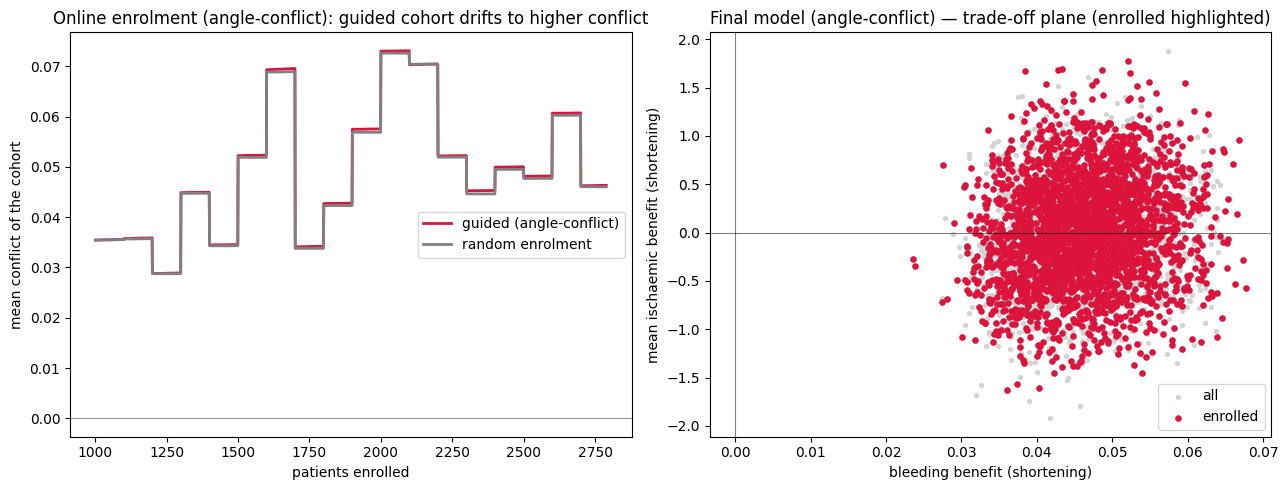

In [11]:
plot_run_diagnostics(run, color='crimson', title_suffix=' (angle-conflict)')

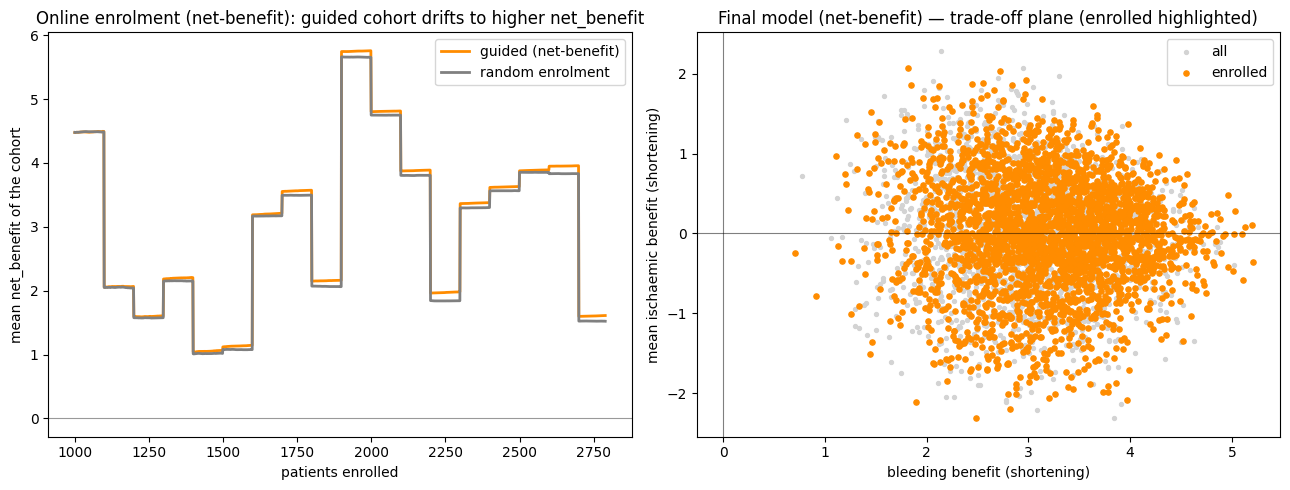

In [12]:
plot_run_diagnostics(run_nb, color='darkorange', title_suffix=' (net-benefit)')

## Evolution of the enrolled cohort

One figure per regime, one axes each: the enrolled cohort cut into consecutive batches in their
true arrival order, plotted on the final model's trade-off plane with opacity increasing batch by
batch -- the first (earliest, mostly seed + early duels) is the most faded, the last (latest) is
fully opaque. Reading left-to-right in the legend traces where the mechanism's attention drifts
as it learns.

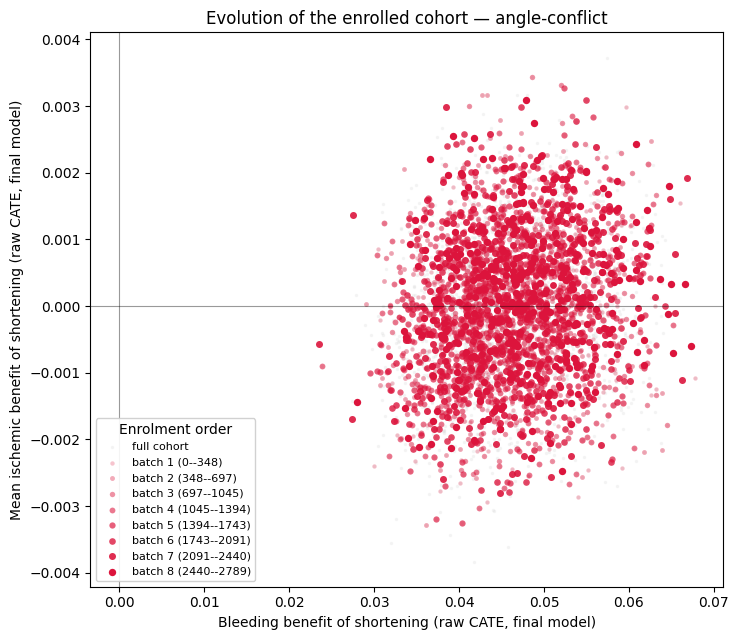

In [13]:
plot_enrolment_evolution(run, color='crimson', title_suffix=' — angle-conflict')

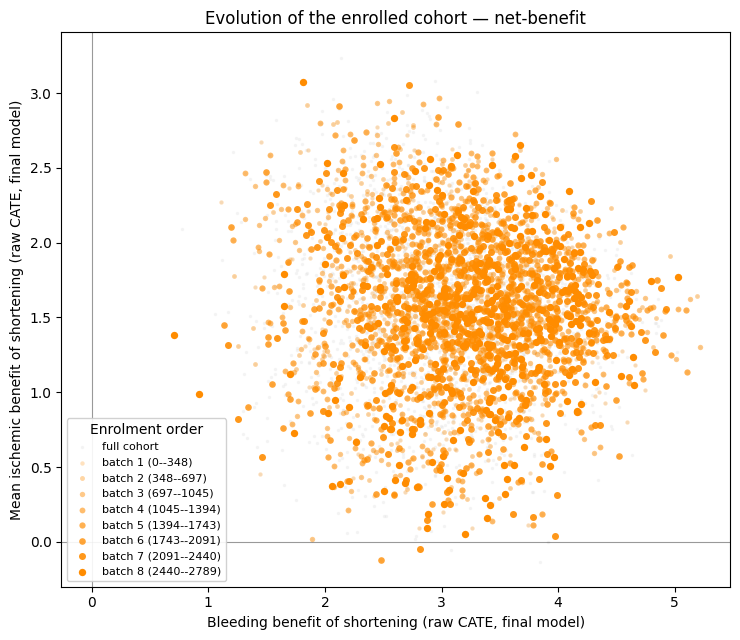

In [14]:
plot_enrolment_evolution(run_nb, color='darkorange', title_suffix=' — net-benefit')

## Repeated simulations — 30 seeds, parallel, average performance

A single run's enrolled cohort is one draw of the random arrival order; to see whether either
mechanism's effect is a stable pattern or an artefact of one seed, phase 1 + phase 2 are repeated
30 times (`seed = 42 + run_id`), **both regimes sharing the same per-run seed-tuned forest** --
exactly like the single primary runs above, just 30 times over. Each worker gets
`TOTAL_CORES // N_RUNS` cores; `Parallel(n_jobs=N_RUNS)` runs the 30 seeds at once.

**Included vs excluded.** For each regime, `included` = the online-enrolled patients minus the
seed (`enrolled[len(seed_idx):]`) -- the ones the duel actually chose; `excluded` = the duel
losers (`unenrolled`) -- seen at the pairwise stage and discarded. The seed cohort is left out of
both groups: it was given directly, before any model existed to choose it, so folding it into
either side would dilute a comparison that is specifically about the duel's decision. The observed
(real, recorded) event rate on all four endpoints -- bleed, MI, stroke, death -- is computed for
both groups in every run, then averaged over the 30 runs.

In [15]:
from joblib import Parallel, delayed

N_RUNS = 50

TOTAL_CORES     = os.cpu_count() or 32
FIT_N_JOBS      = max(TOTAL_CORES // N_RUNS, 1)
FIT_LGBM_N_JOBS = max(FIT_N_JOBS // 2, 1)   # same 2:1 CF:LightGBM ratio as the module default 32:16

REGIMES = {
    'angle-conflict': dict(duel=duel_by_angle,       score_fn=conflict_from_model,    score_col='conflict',     scale_score=False),
    'net-benefit':    dict(duel=duel_by_net_benefit, score_fn=net_benefit_from_model, score_col='net_benefit',  scale_score=True),
}


def one_run(run_id):
    """One seed: tune once, then run BOTH regimes from that same seed-tuned forest (mirrors the
    single primary runs above). Returns long-format rows: one per (regime, endpoint, group)."""
    seed = 42 + run_id
    prep_r = seed_fit_tune(N_SEED, seed=seed, n_trials=N_TRIALS, n_test=N_TEST, verbose=False,
                           n_jobs=FIT_N_JOBS, lgbm_n_jobs=FIT_LGBM_N_JOBS)
    seed_n = len(prep_r['seed_idx'])

    rows = []
    for regime, cfg in REGIMES.items():
        run_r = run_online(prep_r, N_STEPS, verbose=False,
                           n_jobs=FIT_N_JOBS, lgbm_n_jobs=FIT_LGBM_N_JOBS, **cfg)
        included = run_r['enrolled'][seed_n:]
        excluded = run_r['unenrolled']
        for k, col in ENDPOINTS.items():
            yr = y[col].to_numpy()
            rows.append(dict(run=run_id, regime=regime, endpoint=k, group='included',
                             rate=yr[included].mean(), n=len(included)))
            rows.append(dict(run=run_id, regime=regime, endpoint=k, group='excluded',
                             rate=yr[excluded].mean(), n=len(excluded)))
    return rows


runs = Parallel(n_jobs=N_RUNS, verbose=10)(delayed(one_run)(run_id) for run_id in range(N_RUNS))
results_df = pd.DataFrame([row for run_rows in runs for row in run_rows])

[Parallel(n_jobs=50)]: Using backend LokyBackend with 50 concurrent workers.


PHASE 1  seed drawn: 1000 patients  |  stream: 3579  |  held-out: 0
PHASE 1  initial fit on 1000 seed patients ...
PHASE 1  seed drawn: 1000 patients  |  stream: 3579  |  held-out: 0
PHASE 1  initial fit on 1000 seed patients ...
PHASE 1  seed drawn: 1000 patients  |  stream: 3579  |  held-out: 0
PHASE 1  initial fit on 1000 seed patients ...
PHASE 1  seed drawn: 1000 patients  |  stream: 3579  |  held-out: 0
PHASE 1  initial fit on 1000 seed patients ...
PHASE 1  seed drawn: 1000 patients  |  stream: 3579  |  held-out: 0
PHASE 1  initial fit on 1000 seed patients ...
PHASE 1  seed drawn: 1000 patients  |  stream: 3579  |  held-out: 0
PHASE 1  initial fit on 1000 seed patients ...
PHASE 1  seed drawn: 1000 patients  |  stream: 3579  |  held-out: 0
PHASE 1  initial fit on 1000 seed patients ...
PHASE 1  seed drawn: 1000 patients  |  stream: 3579  |  held-out: 0
PHASE 1  initial fit on 1000 seed patients ...
PHASE 1  seed drawn: 1000 patients  |  stream: 3579  |  held-out: 0
PHASE 1  ini

/home/tpioda/Bachelor-Thesis/.venv/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/tpioda/Bachelor-Thesis/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/tpioda/Bachelor-Thesis/.venv/lib/python3.10/site-packages/econml/validate/utils.py:99: RuntimeWarning: invalid value encountered in divide
  toc_psi[it, :] = np.squeeze((dr_val - ate) * (inds / group_prob - 1) - toc[it])
/home/tpioda/Bachelor-Thesis/.venv/lib/python3.10/site-packages/econml/validate/utils.py:106: RuntimeWarning: invalid value encountered in divide
  mboot = (toc_psi / toc_std.reshape(-1, 1)) @ w / n
/home/tpioda/Bachelor-Thesis/.venv/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/tpioda/Ba

PHASE 1  hyper-tuning (20 trials, AUTOC lower bound on bleed) ...
         best CV score = -0.0000   nuisance_level='medium'
         tuned cf_params = {'n_estimators': 345, 'subforest_size': 5, 'max_depth': 4, 'min_samples_leaf': 174, 'max_samples': 0.23224525162126686, 'max_features': 0.7, 'inference': True}
         seed CATE mean=+0.0071  std=0.0205  conflict mean=+0.0378
PHASE 1  hyper-tuning (20 trials, AUTOC lower bound on bleed) ...
PHASE 1  hyper-tuning (20 trials, AUTOC lower bound on bleed) ...


/home/tpioda/Bachelor-Thesis/.venv/lib/python3.10/site-packages/econml/validate/utils.py:106: RuntimeWarning: invalid value encountered in divide
  mboot = (toc_psi / toc_std.reshape(-1, 1)) @ w / n


...

/home/tpioda/Bachelor-Thesis/.venv/lib/python3.10/site-packages/econml/validate/utils.py:106: RuntimeWarning: invalid value encountered in divide
  mboot = (toc_psi / toc_std.reshape(-1, 1)) @ w / n
/home/tpioda/Bachelor-Thesis/.venv/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/tpioda/Bachelor-Thesis/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/tpioda/Bachelor-Thesis/.venv/lib/python3.10/site-packages/econml/validate/utils.py:99: RuntimeWarning: invalid value encountered in divide
  toc_psi[it, :] = np.squeeze((dr_val - ate) * (inds / group_prob - 1) - toc[it])
/home/tpioda/Bachelor-Thesis/.venv/lib/python3.10/site-packages/econml/validate/utils.py:106: RuntimeWarning: invalid value encountered in divide
  mboot = (toc_psi / toc_std.reshape(-1, 1)) @ w / n
/

         best CV score = -0.0000   nuisance_level='flexible'
         tuned cf_params = {'n_estimators': 343, 'subforest_size': 7, 'max_depth': 4, 'min_samples_leaf': 124, 'max_samples': 0.19630581534588565, 'max_features': 0.3, 'inference': True}


/home/tpioda/Bachelor-Thesis/.venv/lib/python3.10/site-packages/econml/validate/utils.py:106: RuntimeWarning: invalid value encountered in divide
  mboot = (toc_psi / toc_std.reshape(-1, 1)) @ w / n


         best CV score = -0.0000   nuisance_level='medium'
         tuned cf_params = {'n_estimators': 416, 'subforest_size': 8, 'max_depth': 30, 'min_samples_leaf': 173, 'max_samples': 0.3062479826872926, 'max_features': 0.5, 'inference': True}
         best CV score = -0.0000   nuisance_level='regularized'
         tuned cf_params = {'n_estimators': 384, 'subforest_size': 12, 'max_depth': None, 'min_samples_leaf': 47, 'max_samples': 0.0971207453009989, 'max_features': 0.5, 'inference': True}
         best CV score = -0.0000   nuisance_level='medium'
         tuned cf_params = {'n_estimators': 180, 'subforest_size': 5, 'max_depth': 8, 'min_samples_leaf': 164, 'max_samples': 0.1880762679460225, 'max_features': 0.3, 'inference': True}
         best CV score = -0.0000   nuisance_level='medium'
         tuned cf_params = {'n_estimators': 230, 'subforest_size': 5, 'max_depth': 15, 'min_samples_leaf': 143, 'max_samples': 0.08640801521680588, 'max_features': 0.3, 'inference': True}
         

[Parallel(n_jobs=50)]: Done  17 out of  50 | elapsed: 12.4min remaining: 24.0min
[Parallel(n_jobs=50)]: Done  23 out of  50 | elapsed: 13.0min remaining: 15.2min
[Parallel(n_jobs=50)]: Done  29 out of  50 | elapsed: 13.4min remaining:  9.7min
[Parallel(n_jobs=50)]: Done  35 out of  50 | elapsed: 14.5min remaining:  6.2min
[Parallel(n_jobs=50)]: Done  41 out of  50 | elapsed: 15.4min remaining:  3.4min
[Parallel(n_jobs=50)]: Done  47 out of  50 | elapsed: 17.0min remaining:  1.1min
[Parallel(n_jobs=50)]: Done  50 out of  50 | elapsed: 18.5min finished


In [16]:
summary = (results_df.groupby(['regime', 'endpoint', 'group'])['rate']
                     .agg(['mean', 'std']).reset_index())

for regime in REGIMES:
    print(f'=== {regime}  (n={N_RUNS} runs) ===')
    piv = summary[summary['regime'] == regime].pivot(index='endpoint', columns='group', values=['mean', 'std'])
    n_inc = results_df.query('regime == @regime and group == "included"')['n'].mean()
    n_exc = results_df.query('regime == @regime and group == "excluded"')['n'].mean()
    print(f'  mean n  included={n_inc:.0f}  excluded={n_exc:.0f}')
    for k in ENDPOINTS:
        m_inc, s_inc = piv.loc[k, ('mean', 'included')], piv.loc[k, ('std', 'included')]
        m_exc, s_exc = piv.loc[k, ('mean', 'excluded')], piv.loc[k, ('std', 'excluded')]
        print(f'  {k:7s}  included={m_inc:.4f} ± {s_inc:.4f}   excluded={m_exc:.4f} ± {s_exc:.4f}')
    print()

=== angle-conflict  (n=50 runs) ===
  mean n  included=1789  excluded=1789
  bleed    included=0.1108 ± 0.0065   excluded=0.1112 ± 0.0061
  death    included=0.0179 ± 0.0027   excluded=0.0176 ± 0.0028
  mi       included=0.0247 ± 0.0037   excluded=0.0234 ± 0.0036
  stroke   included=0.0077 ± 0.0014   excluded=0.0074 ± 0.0016

=== net-benefit  (n=50 runs) ===
  mean n  included=1789  excluded=1789
  bleed    included=0.1097 ± 0.0070   excluded=0.1123 ± 0.0063
  death    included=0.0174 ± 0.0028   excluded=0.0180 ± 0.0025
  mi       included=0.0243 ± 0.0028   excluded=0.0239 ± 0.0039
  stroke   included=0.0072 ± 0.0018   excluded=0.0080 ± 0.0016



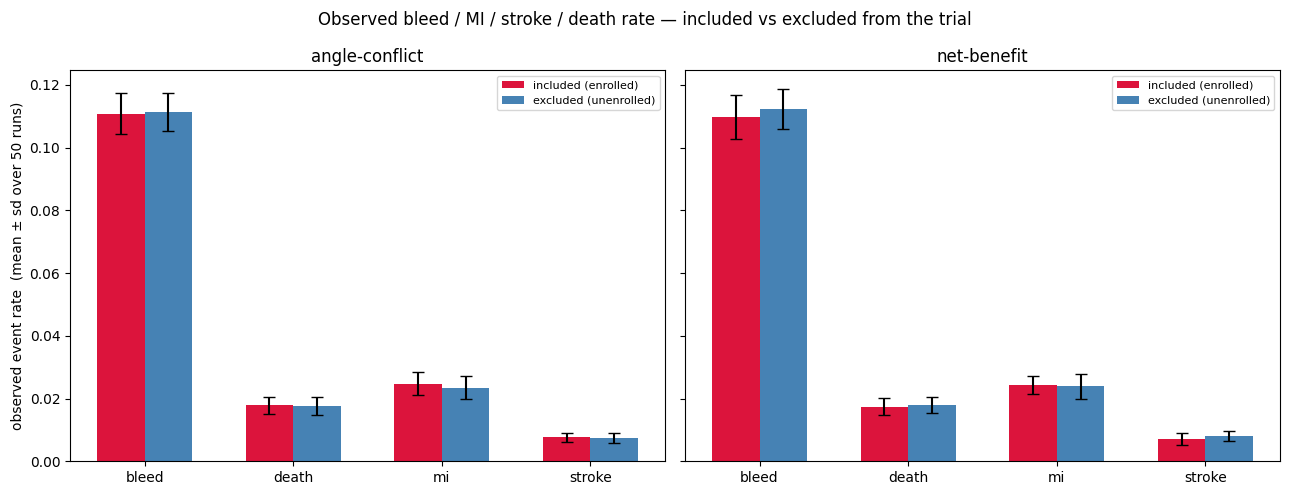

In [17]:
labels = list(ENDPOINTS)
xpos = np.arange(len(labels))
w = 0.32

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, regime in zip(axes, REGIMES):
    sub = summary[summary['regime'] == regime].set_index(['endpoint', 'group'])
    m_inc = [sub.loc[(k, 'included'), 'mean'] for k in labels]
    s_inc = [sub.loc[(k, 'included'), 'std']  for k in labels]
    m_exc = [sub.loc[(k, 'excluded'), 'mean'] for k in labels]
    s_exc = [sub.loc[(k, 'excluded'), 'std']  for k in labels]

    ax.bar(xpos - w / 2, m_inc, width=w, yerr=s_inc, capsize=4, color='crimson',   label='included (enrolled)')
    ax.bar(xpos + w / 2, m_exc, width=w, yerr=s_exc, capsize=4, color='steelblue', label='excluded (unenrolled)')
    ax.set_xticks(xpos); ax.set_xticklabels(labels)
    ax.set_title(regime)
    ax.legend(fontsize=8)

axes[0].set_ylabel(f'observed event rate  (mean ± sd over {N_RUNS} runs)')
fig.suptitle('Observed bleed / MI / stroke / death rate — included vs excluded from the trial')
plt.tight_layout()
plt.show()